# NHL Puck Management — Visualizations

This notebook produces the charts and visuals for the LinkedIn posts 
and Quarto blog. All visualizations are based on the final composite 
puck management rankings for the 2025-26 NHL regular season.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns


In [2]:
# Load final rankings
final_rankings = pd.read_csv('../data/processed/final_rankings.csv')

print(f"Total players: {len(final_rankings)}")
final_rankings.sort_values('composite_score', ascending=False).head(10)

Total players: 715


,name,team,position,games_played,giveaway_metric,dzone_giveaway_metric,avg_above_expected,total_giveaways,icetime_minutes,confidence,above_expected_z,dzone_z,giveaway_weighted,above_expected_weighted,dzone_weighted,giveaway_z,composite_score
710,Brayden McNabb,VGK,D,63,1.890292,0.160494,0.013896,44.0,1093.483333,0.977529,2.056056,2.404942,1.847815,0.013617,0.163685,2.371464,6.832461
565,Alexandre Carrier,MTL,D,73,2.157701,0.173333,0.013839,43.0,1123.516667,1.000000,2.093590,2.237817,2.157701,0.013839,0.173333,2.500000,6.831406
167,Luke Glendening,PHI,C,70,3.300576,0.013072,0.013162,11.0,609.450000,0.610486,1.862018,2.039915,2.014956,0.008424,0.049714,2.500000,6.401933
222,Frederick Gaudreau,SEA,C,68,1.006005,0.034130,0.014587,36.0,916.733333,0.843499,2.500000,2.187593,0.848565,0.012460,0.045556,1.275556,5.963149
467,Mathieu Olivier,CBJ,R,61,2.122178,0.048951,0.010895,23.0,794.550000,0.750848,1.863371,1.552009,1.593432,0.008429,0.063450,2.395185,5.810565
550,Jonas Brodin,MIN,D,62,2.413429,0.171642,0.007671,40.0,1099.116667,0.981801,1.031983,2.225858,2.369507,0.007558,0.174024,2.500000,5.757841
567,Mikey Anderson,LAK,D,80,2.569105,0.156098,0.005282,50.0,1418.500000,1.000000,0.647269,2.500000,2.569105,0.005282,0.156098,2.500000,5.647269
208,Jack Drury,COL,C,82,1.186252,0.058394,0.012512,37.0,983.966667,0.894482,2.500000,1.548872,1.061081,0.011297,0.063538,1.594995,5.643867
646,Albert Johansson,DET,D,82,1.213224,0.200000,0.013771,52.0,1150.050000,1.000000,2.082113,1.775891,1.213224,0.013771,0.200000,1.557037,5.415041
252,Jordan Eberle,SEA,R,80,0.874218,0.064103,0.011667,48.0,1185.516667,1.000000,2.500000,1.528818,0.874218,0.011667,0.064103,1.314116,5.342934


## Chart 1 — Top 20 Puck Managers

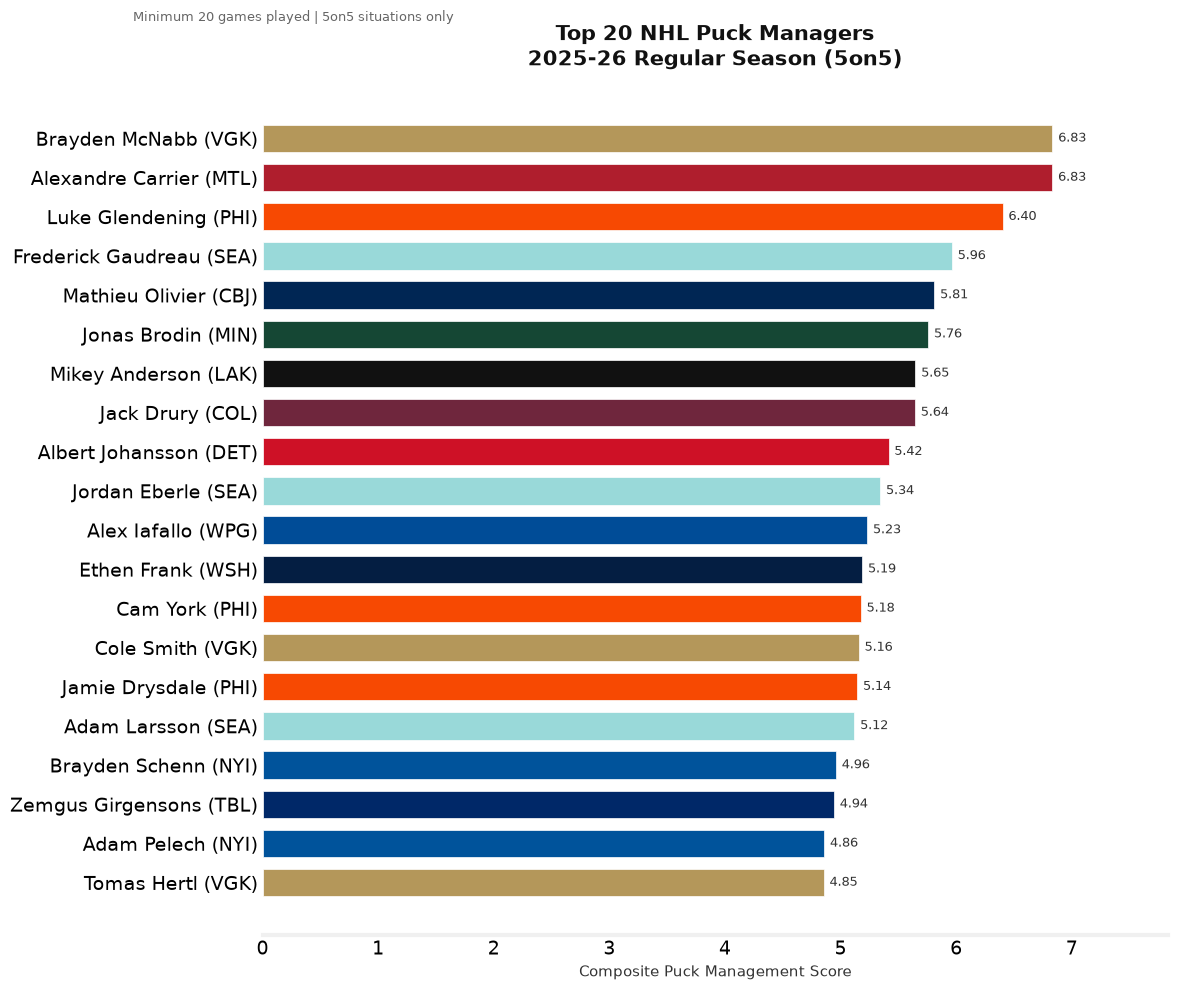

In [5]:
# NHL team primary colors
team_colors = {
    'ANA': '#F47A38', 'ARI': '#8C2633', 'BOS': '#FFB81C', 'BUF': '#003087',
    'CGY': '#C8102E', 'CAR': '#CC0000', 'CHI': '#CF0A2C', 'COL': '#6F263D',
    'CBJ': '#002654', 'DAL': '#006847', 'DET': '#CE1126', 'EDM': '#FF4C00',
    'FLA': '#041E42', 'LAK': '#111111', 'MIN': '#154734', 'MTL': '#AF1E2D',
    'NSH': '#FFB81C', 'NJD': '#CE1126', 'NYI': '#00539B', 'NYR': '#0038A8',
    'OTT': '#C2912C', 'PHI': '#F74902', 'PIT': '#FCB514', 'STL': '#002F87',
    'SJS': '#006D75', 'SEA': '#99D9D9', 'TBL': '#002868', 'TOR': '#00205B',
    'UTA': '#6CACE4', 'VAN': '#00843D', 'VGK': '#B4975A', 'WSH': '#041E42',
    'WPG': '#004C97', 'NYR': '#0038A8'
}

top20 = final_rankings.sort_values('composite_score', ascending=False).head(20).copy()
top20['label'] = top20['name'] + ' (' + top20['team'] + ')'
bar_colors = [team_colors.get(team, '#333333') for team in top20['team']]

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(top20['label'], top20['composite_score'],
               color=bar_colors, edgecolor='white', linewidth=0.5, height=0.7)

# Value labels with 2 decimal places
for bar, val in zip(bars, top20['composite_score']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color='#333333')

ax.invert_yaxis()
ax.set_xlabel('Composite Puck Management Score', fontsize=11, color='#333333')
ax.set_title('Top 20 NHL Puck Managers\n2025-26 Regular Season (5on5)',
             fontsize=15, fontweight='bold', color='#111111', pad=15)
ax.set_xlim(0, top20['composite_score'].max() + 1)

# Remove background lines
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Subtitle
fig.text(0.12, 0.98, 'Minimum 20 games played | 5on5 situations only',
         fontsize=9, color='#666666')

plt.tight_layout()
plt.savefig('../outputs/top20_puck_managers.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 2  — Team Puck Management Rankings

Average composite puck management score by team. Shows which 
organizations have the best puck managers collectively.

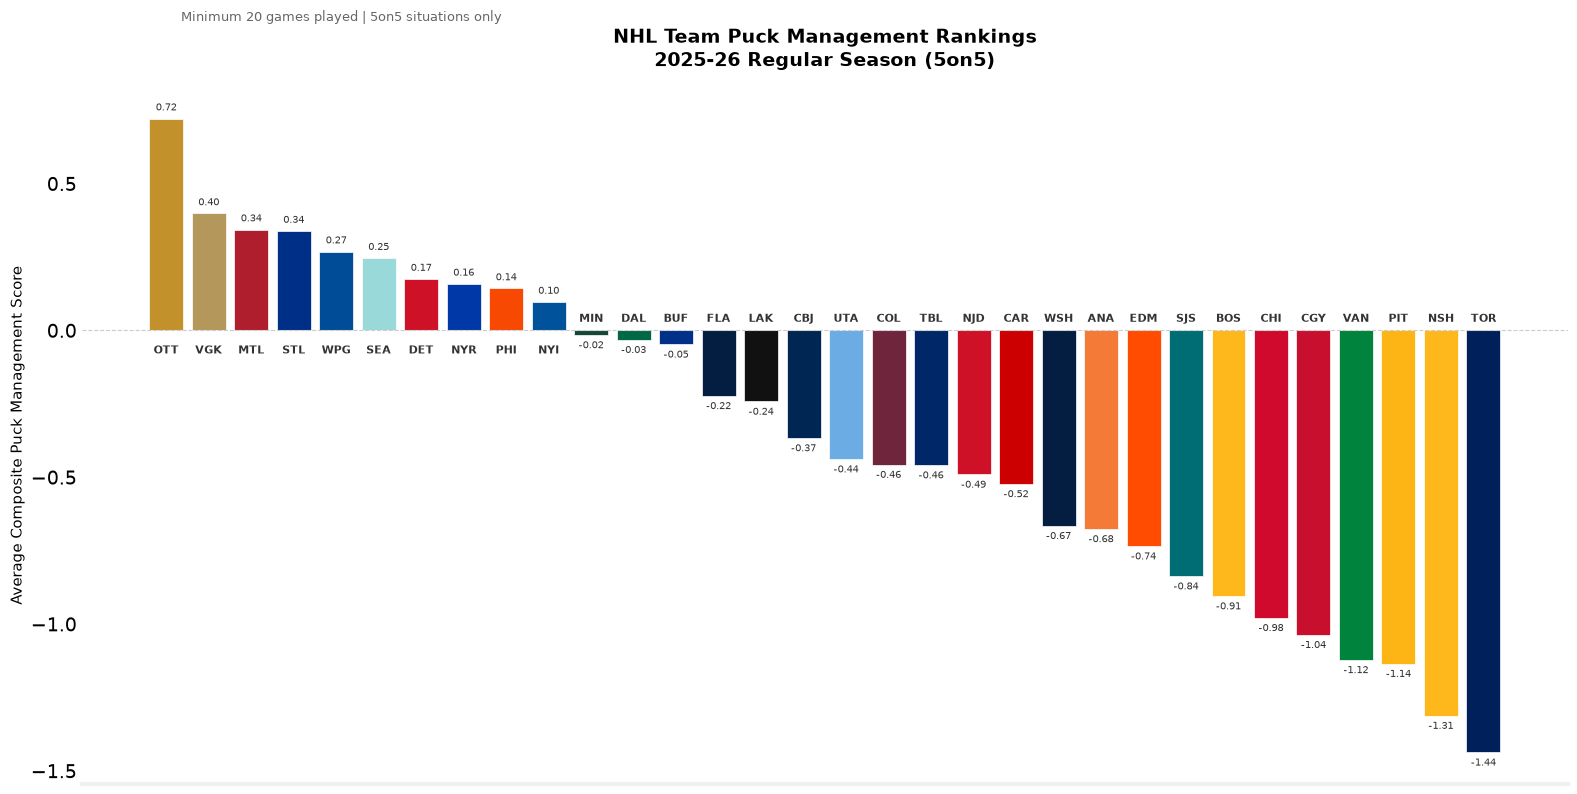

In [10]:
# Average composite score by team
team_rankings = final_rankings.groupby('team').agg(
    avg_score=('composite_score', 'mean'),
    num_players=('composite_score', 'count')
).reset_index().sort_values('avg_score', ascending=False)

bar_colors = [team_colors.get(team, '#333333') for team in team_rankings['team']]

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.bar(range(len(team_rankings)), team_rankings['avg_score'],
              color=bar_colors, edgecolor='white', linewidth=0.5)

# Team labels and scores
for i, (bar, val, team) in enumerate(zip(bars, team_rankings['avg_score'], team_rankings['team'])):
    if val >= 0:
        # Score above bar
        ax.text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom',
                fontsize=7, color='#333333')
        # Team label below x axis
        ax.text(i, -0.05, team, ha='center', va='top',
                fontsize=8, color='#333333', fontweight='bold')
    else:
        # Score below bar
        ax.text(i, val - 0.02, f'{val:.2f}', ha='center', va='top',
                fontsize=7, color='#333333')
        # Team label above x axis
        ax.text(i, 0.02, team, ha='center', va='bottom',
                fontsize=8, color='#333333', fontweight='bold')

ax.set_xticks([])
ax.set_ylabel('Average Composite Puck Management Score', fontsize=11)
ax.set_title('NHL Team Puck Management Rankings\n2025-26 Regular Season (5on5)',
             fontsize=14, fontweight='bold', pad=15)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.axhline(y=0, color='#cccccc', linestyle='--', linewidth=0.8)

fig.text(0.12, 0.98, 'Minimum 20 games played | 5on5 situations only',
         fontsize=9, color='#666666')

plt.tight_layout()
plt.savefig('../outputs/team_puck_management.png', dpi=300, bbox_inches='tight')
plt.show()